# AlphaEarth Embeddings Python Tutorial

## Clustering Example

This python was converted from the original javascript here:

https://developers.google.com/earth-engine/tutorials/community/satellite-embedding-01-introduction

In [3]:
import ee
import geemap
import numpy as np
from tqdm import tqdm

ee.Authenticate()
# Initialize Earth Engine
ee.Initialize(project="ee-ktwu01")

print("Earth Engine initialized successfully!")

Earth Engine initialized successfully!


Use the satellite basemap (Note: Map.setOptions is specific to Code Editor)

In Python, you'll typically use geemap or folium for visualization

In [4]:
## Austin
embeddings = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

geometry = ee.Geometry.Polygon(
    [[[-97.583924, 30.150367], [-97.734003, 30.150367], [-97.734003, 30.269097], [-97.583924, 30.269097]]]
)

In [5]:
AE_START_YEAR = 2017
AE_END_YEAR = 2024


In [6]:
def get_embeddings_image(year):
    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = start_date.advance(1, "year")

    embeddings_image = embeddings.filter(ee.Filter.date(start_date, end_date)).filter(
        ee.Filter.bounds(geometry)
    )
    return embeddings_image.mosaic()

def get_similarity(year1, year2):
    embeddings_year1 = get_embeddings_image(year1)
    embeddings_year2 = get_embeddings_image(year2)
    dot_product = embeddings_year1.multiply(embeddings_year2).reduce(ee.Reducer.sum())
    return dot_product

def get_cosine_similarity(year1, year2):
    a = get_embeddings_image(year1).toFloat()
    b = get_embeddings_image(year2).toFloat()
    dot = a.multiply(b).reduce(ee.Reducer.sum())
    na = a.pow(2).reduce(ee.Reducer.sum()).sqrt()
    nb = b.pow(2).reduce(ee.Reducer.sum()).sqrt()
    return dot.divide(na.multiply(nb)).rename('cos')

def get_average_similarity(sim_img):
    return sim_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).get('cos').getInfo()

In [7]:
similarity_map = {}
mean_similarity = {}

for year in tqdm(range(AE_START_YEAR, AE_END_YEAR), desc="Calculating year-over-year changes"):
    year2 = year + 1
    span_string = f"{year}-{year2}"
    similarity_map[span_string] = get_cosine_similarity(year, year2)
    mean_similarity[span_string] = get_average_similarity(similarity_map[span_string])


Calculating year-over-year changes: 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]


In [8]:
def region_percentiles(img):
    # Returns keys like 'cos_p10', 'cos_p25', etc. and 'cos_stdDev'
    reducers = ee.Reducer.percentile([10,25,50,75,90]).combine(
        ee.Reducer.stdDev(), sharedInputs=True
    )
    return img.reduceRegion(
        reducer=reducers, geometry=geometry, scale=10,
        maxPixels=1e9, bestEffort=True
    )

def area_fraction_below(img, threshold=0.95):
    total_area = ee.Image.pixelArea().reduceRegion(
        ee.Reducer.sum(), geometry, 10, maxPixels=1e9, bestEffort=True
    ).get('area')
    changed_area = img.lt(threshold).multiply(ee.Image.pixelArea()).reduceRegion(
        ee.Reducer.sum(), geometry, 10, maxPixels=1e9, bestEffort=True
    ).get('cos')
    return ee.Number(changed_area).divide(ee.Number(total_area))

def trimmed_mean(img, lower=10, upper=90):
    pct = img.reduceRegion(
        ee.Reducer.percentile([lower, upper]), geometry, 10,
        maxPixels=1e9, bestEffort=True
    )
    pL = ee.Number(pct.get(f'cos_p{lower}'))
    pU = ee.Number(pct.get(f'cos_p{upper}'))
    trimmed = img.updateMask(img.gte(pL).And(img.lte(pU)))
    return trimmed.reduceRegion(
        ee.Reducer.mean(), geometry, 10, maxPixels=1e9, bestEffort=True
    ).get('cos')

In [9]:
# Compute metrics for all year-over-year images
results = []
for y in range(AE_START_YEAR, AE_END_YEAR):
    cos = get_cosine_similarity(y, y+1)
    stats = region_percentiles(cos)
    iqr = ee.Number(stats.get('cos_p75')).subtract(ee.Number(stats.get('cos_p25')))
    frac_below_095 = area_fraction_below(cos, threshold=0.95)
    tmean_10_90 = trimmed_mean(cos, 10, 90)
    results.append(ee.Feature(None, {
        'year2': y+1,
        'p50': stats.get('cos_p50'),
        'IQR': iqr,
        'std': stats.get('cos_stdDev'),
        'frac_below_0_95': frac_below_095,
        'trimmed_mean_10_90': tmean_10_90
    }))

table = ee.FeatureCollection(results)
print(table.getInfo())  # Or aggregate_array on specific fields if the response is big

{'type': 'FeatureCollection', 'columns': {'IQR': 'Float', 'frac_below_0_95': 'Float', 'p50': 'Float', 'std': 'Float', 'system:index': 'String', 'trimmed_mean_10_90': 'Float', 'year2': 'Integer'}, 'features': [{'type': 'Feature', 'geometry': None, 'id': '0', 'properties': {'IQR': 0.03901472067204992, 'frac_below_0_95': 0.5091946921925045, 'p50': 0.9511878026046807, 'std': 0.03946176645970618, 'trimmed_mean_10_90': 0.9463139536100231, 'year2': 2018}}, {'type': 'Feature', 'geometry': None, 'id': '1', 'properties': {'IQR': 0.04291101118423968, 'frac_below_0_95': 0.6367026978341835, 'p50': 0.9394741225682678, 'std': 0.045787089775467534, 'trimmed_mean_10_90': 0.9375956462852743, 'year2': 2019}}, {'type': 'Feature', 'geometry': None, 'id': '2', 'properties': {'IQR': 0.02728163814294582, 'frac_below_0_95': 0.2896831319654415, 'p50': 0.962929350518489, 'std': 0.046295486692657345, 'trimmed_mean_10_90': 0.9603648633543052, 'year2': 2020}}, {'type': 'Feature', 'geometry': None, 'id': '3', 'prope

In [10]:
import ee
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pull arrays of each property from the FeatureCollection
props = ['year2','p50','IQR','std','frac_below_0_95','trimmed_mean_10_90']
vals = {p: table.aggregate_array(p).getInfo() for p in props}

# Build DataFrame and sort by year
df = pd.DataFrame(vals).sort_values('year2').reset_index(drop=True)

# Optional: inspect
display(df)

,year2,p50,IQR,std,frac_below_0_95,trimmed_mean_10_90
0,2018,0.951188,0.039015,0.039462,0.509195,0.946314
1,2019,0.939474,0.042911,0.045787,0.636703,0.937596
2,2020,0.962929,0.027282,0.046295,0.289683,0.960365
3,2021,0.962937,0.027245,0.049240,0.283959,0.960636
4,2022,0.959015,0.023335,0.045979,0.308289,0.957954
5,2023,0.970751,0.023360,0.055186,0.205298,0.967324
6,2024,0.955102,0.027270,0.046955,0.402391,0.953483


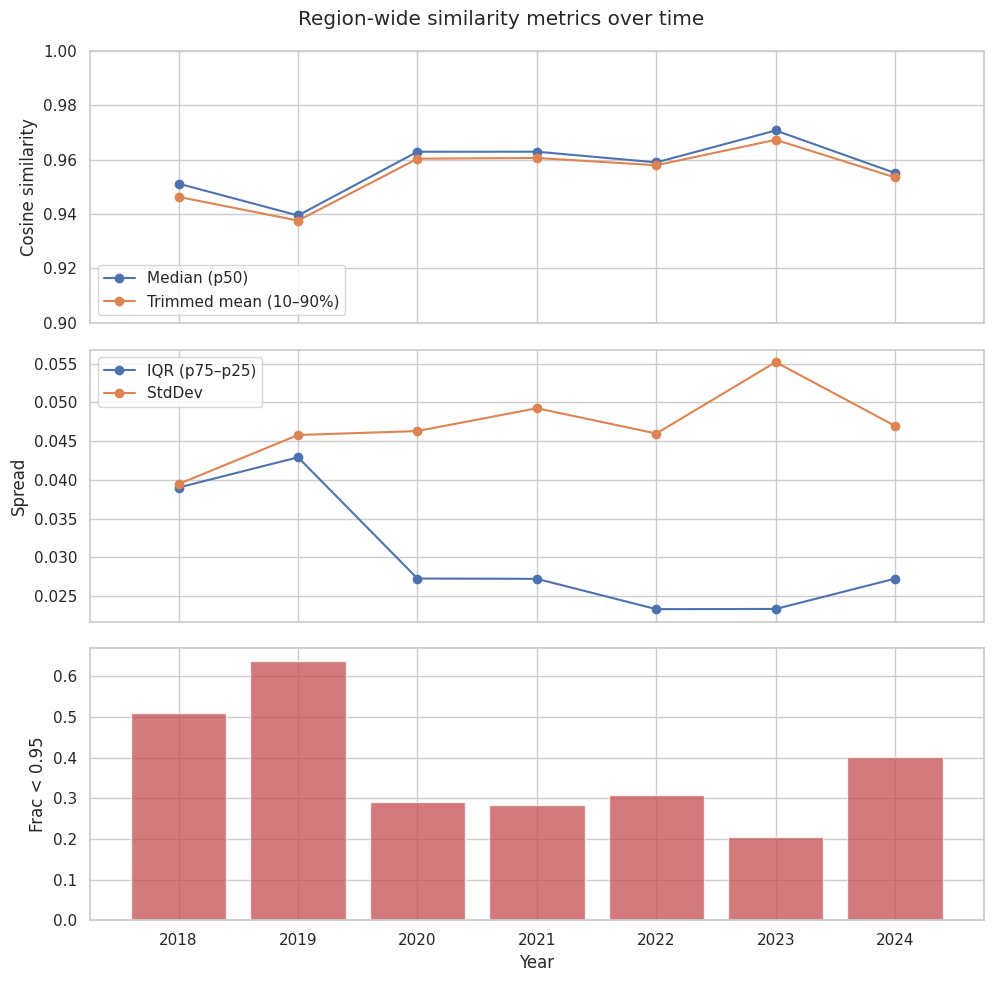

In [11]:
sns.set(style='whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 1) Central tendency
axes[0].plot(df['year2'], df['p50'], marker='o', label='Median (p50)')
axes[0].plot(df['year2'], df['trimmed_mean_10_90'], marker='o', label='Trimmed mean (10–90%)')
axes[0].set_ylabel('Cosine similarity')
axes[0].set_ylim(0.9, 1.0)  # adjust as needed
axes[0].legend(loc='lower left')

# 2) Spread
axes[1].plot(df['year2'], df['IQR'], marker='o', label='IQR (p75–p25)')
axes[1].plot(df['year2'], df['std'], marker='o', label='StdDev')
axes[1].set_ylabel('Spread')
axes[1].legend(loc='upper left')

# 3) Area fraction below threshold
axes[2].bar(df['year2'], df['frac_below_0_95'], color='C3', alpha=0.75)
axes[2].set_ylabel('Frac < 0.95')
axes[2].set_xlabel('Year')

plt.suptitle('Region-wide similarity metrics over time')
plt.tight_layout()
plt.show()

In [23]:
# from google.colab import drive
# drive.mount('/content/drive',force_remount=True)  # Change folder name here

Mounted at /content/drive


In [30]:
# %%bash
# cd /content/drive/My\ Drive/AlphaEarthHack
# ls
# pwd

In [26]:
# # Export the DataFrame to a CSV file
# %ls
# df.to_csv('/similarity_metrics_austin.csv', index=False)
# %ls
# print("DataFrame exported")

drive/  sample_data/  similarity_metrics_austin.csv
drive/  sample_data/  similarity_metrics_austin.csv
DataFrame exported


In [34]:
import json

# Prepare the data in a dictionary format including only labels and data
chart_data = {
    'labels': df['year2'].tolist(),
    'datasets': [
        {
            'label': 'Median (p50)',
            'data': [round(x, 4) for x in df['p50'].tolist()],
        },
        {
            'label': 'Trimmed mean (10 to 90%)',
            'data': [round(x, 4) for x in df['trimmed_mean_10_90'].tolist()],
        },
        {
            'label': 'IQR (p75 to p25)',
            'data': [round(x, 4) for x in df['IQR'].tolist()],
        },
         {
            'label': 'StdDev',
            'data': [round(x, 4) for x in df['std'].tolist()],
        },
         {
            'label': 'Frac < 0.95',
            'data': [round(x, 4) for x in df['frac_below_0_95'].tolist()],
        }
    ]
}

# Print the data as a JSON object (which is close to a JS object literal)
print(json.dumps(chart_data, indent=4))

{
    "labels": [
        2018,
        2019,
        2020,
        2021,
        2022,
        2023,
        2024
    ],
    "datasets": [
        {
            "label": "Median (p50)",
            "data": [
                0.9512,
                0.9395,
                0.9629,
                0.9629,
                0.959,
                0.9708,
                0.9551
            ]
        },
        {
            "label": "Trimmed mean (10 to 90%)",
            "data": [
                0.9463,
                0.9376,
                0.9604,
                0.9606,
                0.958,
                0.9673,
                0.9535
            ]
        },
        {
            "label": "IQR (p75 to p25)",
            "data": [
                0.039,
                0.0429,
                0.0273,
                0.0272,
                0.0233,
                0.0234,
                0.0273
            ]
        },
        {
            "label": "StdDev",
            "data": [
 

Plot the mean similarity scores over time. The LOWEST scores represent the most change.

In [12]:
Map = geemap.Map()
Map.centerObject(geometry, 12)
Map.addLayer(similarity_map['2019-2020'].clip(geometry), {'min': 0, 'max': 1, 'palette': ['blue', 'white']}, 'Dot Product')
Map

Map(center=[30.20974142950009, -97.6589635000009], controls=(WidgetControl(options=['position', 'transparent_b…